# WSTĘPNA ANALIZA ZBIORU DANYCH

###  Telco Customer Churn

In [48]:

from copy import deepcopy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from constants import (
    CHURN,
    DATA_FILE,
    MONTHLY_CHARGES,
    TENURE,
    NUMERIC_COLUMNS,
    CATEGORICAL_COLUMNS,
    CONTRACT,
    INTERNET_SERVICE,
    ONLINE_SECURITY,
    PAYMENT_METHOD,
    TECH_SUPPORT

)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Plik z danymi:", DATA_FILE)


Plik z danymi: resources\WA_Fn-UseC_-Telco-Customer-Churn.csv


## Załadowanie pliku i EDA

In [49]:
data = pd.read_csv(DATA_FILE)

for column in NUMERIC_COLUMNS:
    data[column] = pd.to_numeric(data[column], errors="coerce")
    

def numeric_statistics(df: pd.DataFrame) -> pd.DataFrame:
    numeric_data = df[NUMERIC_COLUMNS]

    statistics = pd.DataFrame(
        {
            "srednia": numeric_data.mean(),
            "mediana": numeric_data.median(),
            "min": numeric_data.min(),
            "max": numeric_data.max(),
            "odchylenie_standardowe": numeric_data.std(),
        }
    )

    return pd.DataFrame(statistics.round(2))


print("Pierwsze 5 wierszy:")
display(data.head())

print("Informacje o kolumnach:")
data.info()

print("Podstawowe statystyki dla cech numerycznych z pandas:")
display(data[NUMERIC_COLUMNS].describe().round(2))

print("podstawowe obliczone ręcznie statystkiki dla cech numerycznych")
display(numeric_statistics(data))



Pierwsze 5 wierszy:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Informacje o kolumnach:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.00,7043.00,7032.00,7043.00
mean,32.37,64.76,2283.30,0.16
std,24.56,30.09,2266.77,0.37
min,0.00,18.25,18.80,0.00
25%,9.00,35.50,401.45,0.00
50%,29.00,70.35,1397.48,0.00
75%,55.00,89.85,3794.74,0.00
max,72.00,118.75,8684.80,1.00


podstawowe obliczone ręcznie statystkiki dla cech numerycznych


,srednia,mediana,min,max,odchylenie_standardowe
tenure,32.37,29.00,0.00,72.00,24.56
MonthlyCharges,64.76,70.35,18.25,118.75,30.09
TotalCharges,2283.30,1397.48,18.80,8684.80,2266.77
SeniorCitizen,0.16,0.00,0.00,1.00,0.37


## Wybrane ciekawe zależności i dane

In [50]:
def tenure_histogram(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=TENURE, bins=20, color="skyblue", edgecolor="black")
    plt.title("Histogram: czas trwania umowy")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def tenure_churn_boxplot(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=TENURE)
    plt.title("Boxplot: czas trwania umowy wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("czas trwania umowy")
    plt.tight_layout()
    plt.show()


def monthly_charges_histogram(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=MONTHLY_CHARGES, bins=20, color="orange", edgecolor="black")
    plt.title("Histogram: miesieczna oplata")
    plt.xlabel("miesieczna oplata")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def monthly_charges_churn_boxplot(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=MONTHLY_CHARGES)
    plt.title("Boxplot: miesieczna oplata wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("miesieczna oplata")
    plt.tight_layout()
    plt.show()


def tenure_monthly_charges_scatter(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=TENURE, y=MONTHLY_CHARGES, hue=CHURN, alpha=0.7)
    plt.title("Wykres rozrzutu: czas trwania umowy i miesieczna oplata")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("miesieczna oplata")
    plt.legend(title="Rezygnacja")
    plt.tight_layout()
    plt.show()


## Dlaczego te 5 wykresow

- `tenure` - pokazuje, jak dlugo klient korzysta z uslug. Nowi klienci zwykle czesciej rezygnuja.
- `MonthlyCharges` - pokazuje miesieczny koszt uslug. Wysoka oplata moze zwiekszac ryzyko odejscia.
- `tenure` vs `Churn` - pozwala sprawdzic, czy klienci odchodzacy maja krotszy czas korzystania z uslug.
- `MonthlyCharges` vs `Churn` - pokazuje, czy osoby odchodzace placa wiecej niz pozostali klienci.
- `tenure` vs `MonthlyCharges` - pozwala zobaczyc zaleznosc miedzy dlugoscia umowy i wysokoscia oplat.


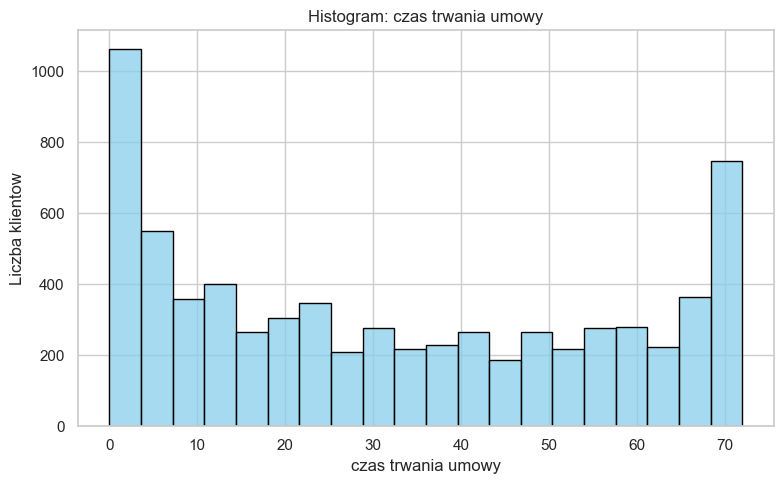

In [51]:
tenure_histogram(data)


Histogram wykazuje rozkład bimodalny. Najliczniejsze grupy stanowią nowi klienci (0-5 miesięcy) oraz klienci długoterminowi (powyżej 65 miesięcy).


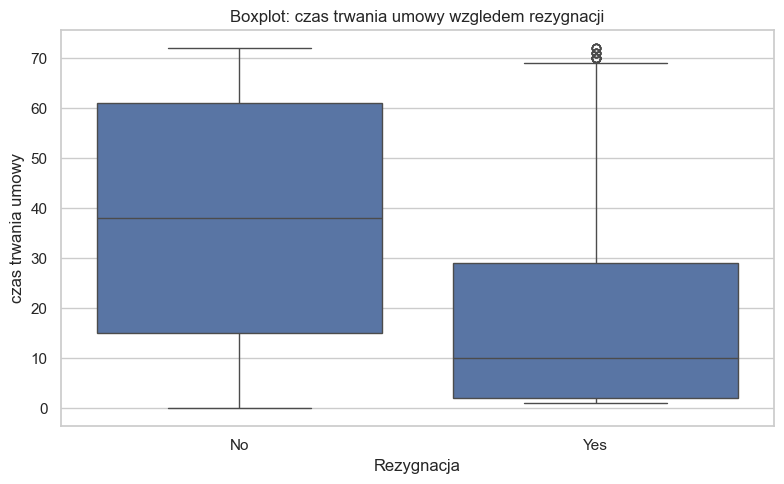

In [52]:
tenure_churn_boxplot(data)


Mediana stażu umowy dla osób rezygnujących (ok. 10 mies.) jest drastycznie niższa niż dla osób pozostających (ok. 38 mies.). 75% wszystkich odejść następuje przed upływem 30 miesiąca trwania umowy.

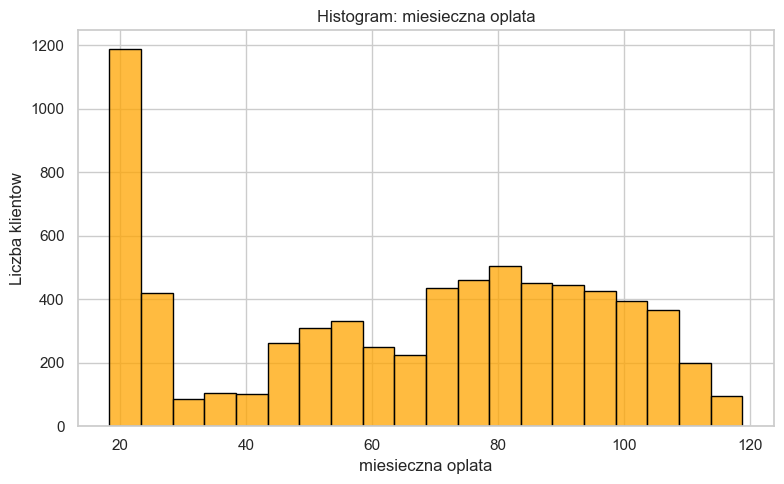

In [53]:
monthly_charges_histogram(data)


 Wyraźna segmentacja klientów na dwie grupy: "Low-tier" (opłaty ok. 20 zł) oraz "High-tier" (opłaty 70-100 zł) Bardzo mała liczebność segmentu średniego (40-60 zł).
 

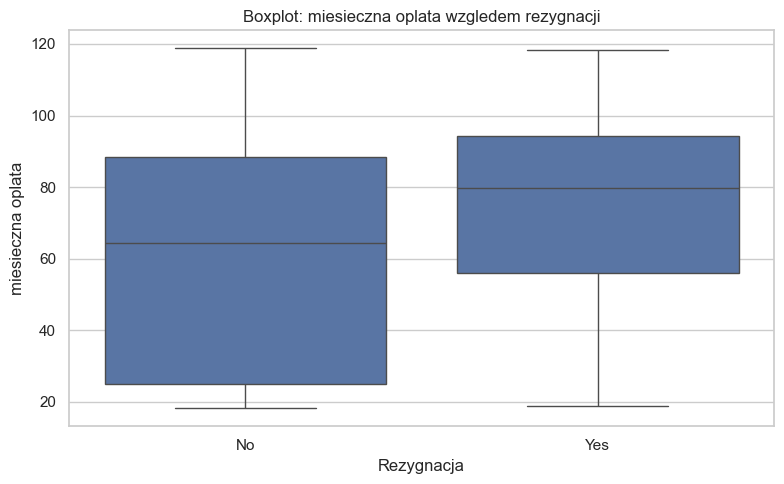

In [54]:
monthly_charges_churn_boxplot(data)


Klienci rezygnujący płacą średnio o ok. 25% wyższe stawki miesięczne niż klienci lojalni (mediana ok. 80 zł vs 65 zł).

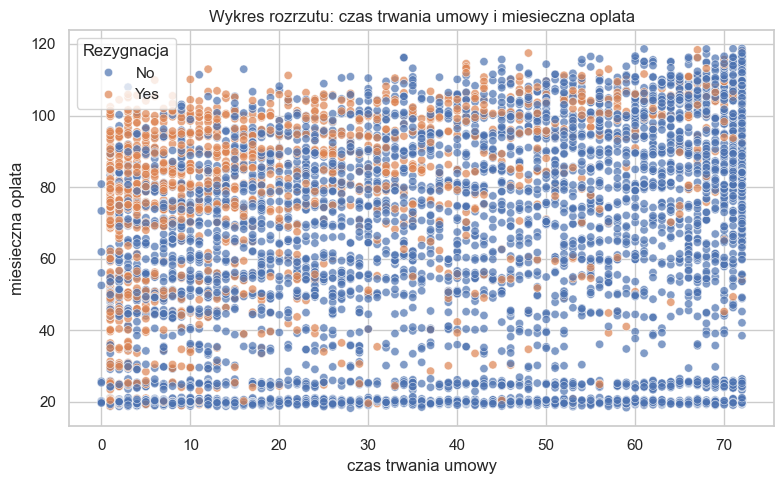

In [55]:
tenure_monthly_charges_scatter(data)


Największa gęstość rezygnacji (punkty pomarańczowe) występuje w obszarze krótkiego stażu i wysokich opłat (lewy górny róg wykresu).

## wniosek

Najbardziej obiecujace cechy to `tenure` (czas trwania umowy) i `MonthlyCharges` (opłaty miesięczne), bo bezposrednio pokazuja, jak dlugo klient zostaje i ile placi. To zwykle pomaga zrozumiec, kto ma wieksze ryzyko rezygnacji.


## Podział na training set i test set

In [ ]:
from sklearn.model_selection import train_test_split

train_df: pd.DataFrame
test_df: pd.DataFrame

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data[CHURN])
display(train_df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2142,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,...,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.80,No
1623,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
6074,3797-VTIDR,Male,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
1362,2568-BRGYX,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No


## EDA na danych kategorialnych

In [57]:
categorial_df = train_df[CATEGORICAL_COLUMNS]


def get_categorial_stats(df: pd.DataFrame) -> pd.DataFrame:
    basic_stats = df.describe().round(2)
    top_prop = pd.DataFrame((basic_stats.loc['freq'] / basic_stats.loc['count'] * 100).round(2)).T
    top_prop.index = ['top_share_%']
    full_eda = pd.concat([basic_stats, top_prop], axis=0)
    return full_eda


categorial_df.info()
display(get_categorial_stats(categorial_df))


<class 'pandas.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5634 non-null   str  
 1   gender            5634 non-null   str  
 2   Partner           5634 non-null   str  
 3   Dependents        5634 non-null   str  
 4   PhoneService      5634 non-null   str  
 5   MultipleLines     5634 non-null   str  
 6   InternetService   5634 non-null   str  
 7   OnlineSecurity    5634 non-null   str  
 8   OnlineBackup      5634 non-null   str  
 9   DeviceProtection  5634 non-null   str  
 10  TechSupport       5634 non-null   str  
 11  StreamingTV       5634 non-null   str  
 12  StreamingMovies   5634 non-null   str  
 13  Contract          5634 non-null   str  
 14  PaperlessBilling  5634 non-null   str  
 15  PaymentMethod     5634 non-null   str  
dtypes: str(16)
memory usage: 748.3 KB


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634
unique,5634,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,4223-BKEOR,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,2887,2904,3951,5082,2685,2481,2810,2448,2489,2791,2239,2223,3083,3325,1887
top_share_%,0.02,51.24,51.54,70.13,90.2,47.66,44.04,49.88,43.45,44.18,49.54,39.74,39.46,54.72,59.02,33.49


In [58]:

def plot_encoded_categorical_feature(
    df: pd.DataFrame,
    column: str,
    title: str,
    tick_labels: list[str],
) -> None:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=column, hue=CHURN)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Liczba klientow")
    plt.xticks(ticks=range(len(tick_labels)), labels=tick_labels, rotation=20)
    plt.tight_layout()
    plt.show()


selected_categorical_features = [
    CONTRACT,
    INTERNET_SERVICE,
    PAYMENT_METHOD,
    TECH_SUPPORT,
    ONLINE_SECURITY,
]




### Krotkie uzasadnienie

- `Contract` - umowa miesieczna zwykle oznacza wieksze ryzyko rezygnacji i daje prostą regule decyzyjna.
- `InternetService` - rodzaj internetu moze wskazywac na roznice w cenie i jakosci uslugi.
- `PaymentMethod` - sposob platnosci czesto dzieli bardziej stabilnych i mniej stabilnych klientow.
- `TechSupport` - brak wsparcia technicznego moze zwiekszac frustracje i rezygnacje.
- `OnlineSecurity` - dodatkowe zabezpieczenia moga zmniejszac ryzyko odejscia klienta.


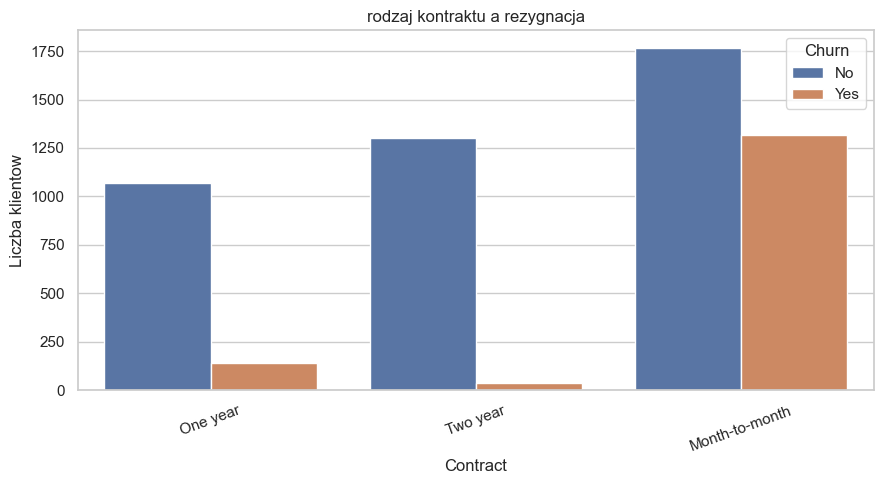

In [ ]:
plot_encoded_categorical_feature(categorial_df, CONTRACT, "rodzaj kontraktu a rezygnacja", ["Month-to-month", "One year", "Two year"])


Typ umowy (Contract) wykazuje silną zależność z rezygnacją. Najwyższy wskaźnik Churn dotyczy umów Month-to-month, co potwierdza, że brak długoterminowego zobowiązania jest kluczowym predyktorem odejścia

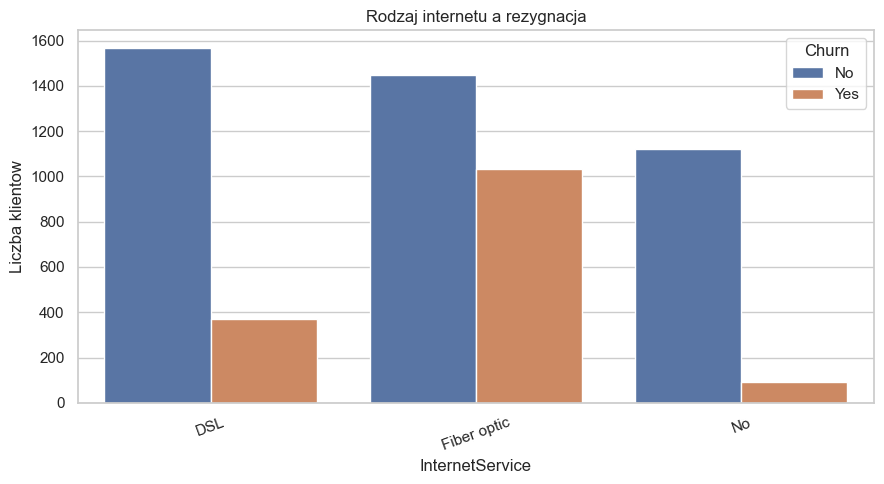

In [ ]:
plot_encoded_categorical_feature(categorial_df, INTERNET_SERVICE, "Rodzaj internetu a rezygnacja", ["No", "DSL", "Fiber optic"])


Użytkownicy Fiber optic (światłowód) odchodzą znacznie częściej niż pozostali. Liczba rezygnacji w tej grupie jest niemal zbliżona do liczby osób, które zostają. Z kolei osoby bez internetu (No) odchodzą sporadycznie.

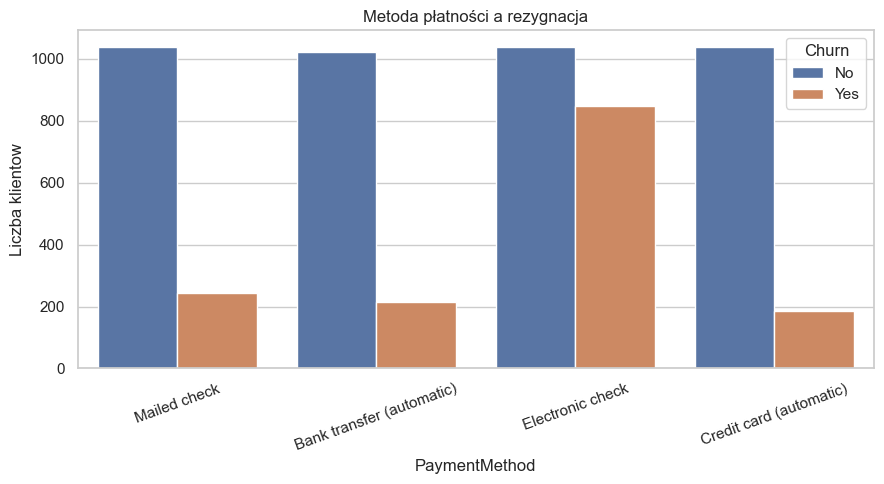

In [ ]:
plot_encoded_categorical_feature(categorial_df, PAYMENT_METHOD, "Metoda p?atno?ci a rezygnacja", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])


Metoda Electronic check wyróżnia się na tle innych drastycznie wysokim słupkiem rezygnacji. Pozostałe metody (przelewy automatyczne czy karta) wykazują znacznie większą lojalność klientów.

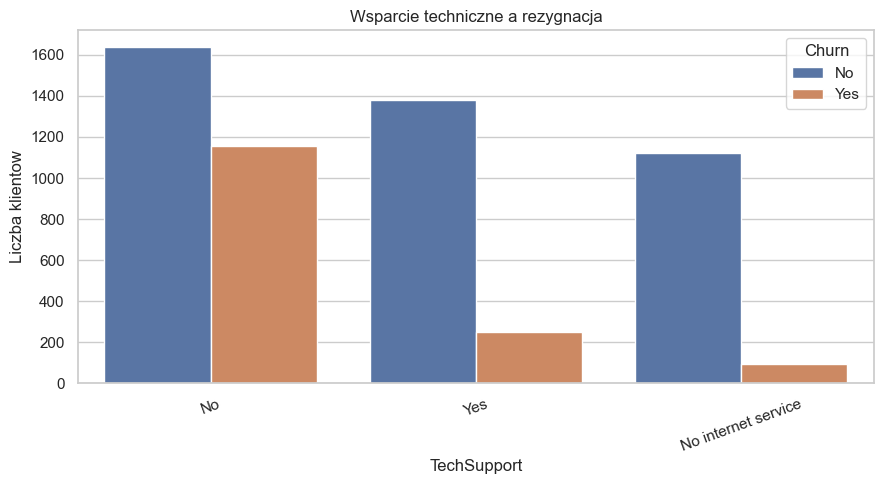

In [ ]:
plot_encoded_categorical_feature(categorial_df, TECH_SUPPORT, "Wsparcie techniczne a rezygnacja", ["No", "Yes", "Brak internetu"])


Osoby, które nie korzystają z wsparcia technicznego (No), rezygnują masowo. Z kolei klienci mający zapewniony TechSupport (Yes) odchodzą rzadko.

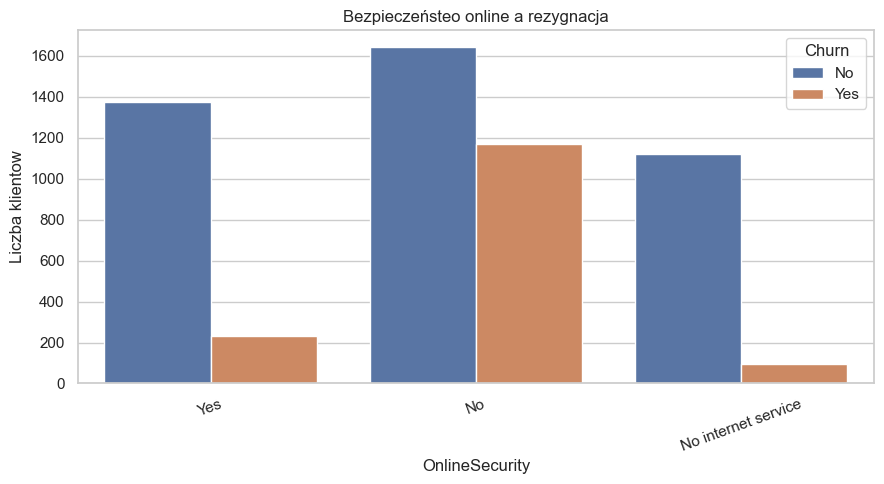

In [ ]:
plot_encoded_categorical_feature(categorial_df, ONLINE_SECURITY, "Bezpiecze?steo online a rezygnacja", ["No", "Yes", "Brak internetu"])


Wykres jest niemal identyczny jak w przypadku TechSupport. Brak usługi OnlineSecurity drastycznie zwiększa prawdopodobieństwo rezygnacji.

## Mapowanie cech kategorialnych na liczby

Zamieniam wybrane cechy tekstowe na wartosci liczbowe. Dzieki temu latwiej jest je pozniej wykorzystac w prostych regułach lub w dalszej analizie. Dla cech binarnych uzywam mapowania `No -> 0` i `Yes -> 1`. Dla cech z wieksza liczba kategorii stosuje osobne mapy slownikowe.

In [ ]:
simple_binary_mapping = {
    "No": 0,
    "Yes": 1,
}

service_binary_mapping = {
    "No": 0,
    "Yes": 1,
    "No internet service": 2,
    "No phone service": 2,
}

contract_mapping = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2,
}

internet_service_mapping = {
    "No": 0,
    "DSL": 1,
    "Fiber optic": 2,
}

payment_method_mapping = {
    "Electronic check": 0,
    "Mailed check": 1,
    "Bank transfer (automatic)": 2,
    "Credit card (automatic)": 3,
}

encoded_train_df = train_df.copy()

